# **Mini Project Sesi 1**
Nama: Faraday Barr Fatahillah

### **Dataset**

Dataset: https://www.kaggle.com/datasets/amaymishra11/student-placement-and-salary-dataset-skills-based

**Problem Statement:**\
Specific: Fokus pada penelitian apakah setiap jurusan mempengaruhi salary untuk meningkatkan kualitas mahasiswa yang lulus, karena semakin besar bayaran semakin tinggi kualitas mahasiswa yang dibutuhkan.


Measureable: IPK (CGPA), Jurusan (branch) dan Gaji (salary_lpa).


Achievable: Mengidentifikasi jurusan mana yang perlu ditingkatkan kurikulumnya berdasarkan data gaji alumni, sebagai rekomendasi kepada pihak akademik.


Relevant: Relevan bagi institusi pendidikan untuk mengevaluasi program studi berdasarkan outcome karir lulusan, khususnya dari sisi kompensasi.


Time bound: Dilakukan dalam waktu 3 bulan menggunakan dataset yang tersedia, dengan hasil digunakan sebagai bahan evaluasi sebelum periode akreditasi selanjutnya.

### Import Library

In [121]:
# import important library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Data Loading

In [122]:
# load dataset
df = pd.read_csv('student_placement_salary_elite_v2.csv')

# show 5 pertama
df.head()

,student_id,cgpa,branch,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,company_type,job_role,salary_lpa
0,S0,6.87,Civil,1,1,1,0,0,15.6,4.3,92.0,1,3,0,62.6,2,1,MNC,Software Engineer,63.55
1,S1,6.52,Civil,2,1,0,0,1,13.9,5.8,62.0,1,6,0,77.5,2,1,MNC,Data Scientist,75.17
2,S2,5.33,IT,1,1,1,1,0,9.8,8.1,66.4,0,5,1,76.0,3,1,MNC,Software Engineer,80.44
3,S3,6.04,Civil,3,1,0,1,0,39.5,9.6,83.6,0,6,0,74.3,2,1,MNC,Software Engineer,72.11
4,S4,6.78,Mechanical,2,0,1,0,1,7.5,9.9,86.3,0,3,0,66.8,2,1,Mid-size,Software Engineer,67.05


In [123]:
#  melihat tipe data, panjang baris, non-null value
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9000 non-null   str    
 1   cgpa                 9000 non-null   float64
 2   branch               9000 non-null   str    
 3   college_tier         9000 non-null   int64  
 4   python_skill         9000 non-null   int64  
 5   dsa_skill            9000 non-null   int64  
 6   ml_skill             9000 non-null   int64  
 7   web_dev_skill        9000 non-null   int64  
 8   coding_score         9000 non-null   float64
 9   communication_score  9000 non-null   float64
 10  aptitude_score       9000 non-null   float64
 11  internships          9000 non-null   int64  
 12  projects             9000 non-null   int64  
 13  backlogs             9000 non-null   int64  
 14  resume_score         9000 non-null   float64
 15  skill_score          9000 non-null   int64  
 16 

In [124]:
# cek unique values (hanya untuk perbandingan manual)
for col in df.columns:
    print('')
    print(f'Column {col}: {df[col].unique()}')


Column student_id: <StringArray>
[   'S0',    'S1',    'S2',    'S3',    'S4',    'S5',    'S6',    'S7',
    'S8',    'S9',
 ...
 'S8990', 'S8991', 'S8992', 'S8993', 'S8994', 'S8995', 'S8996', 'S8997',
 'S8998', 'S8999']
Length: 9000, dtype: str

Column cgpa: [ 6.87  6.52  5.33  6.04  6.78  9.57  8.85  8.78  7.59  8.4   6.6   9.19
  6.7   6.53  6.84  8.84  9.26  5.68  8.98  5.19  5.21  6.4   5.09  5.35
  6.07  8.68  7.67  6.47  8.09  7.96  8.73  9.85  8.23  9.55  9.15  9.72
  7.6   8.18  9.9   7.58  9.    8.6   6.61  6.42  9.21  7.86  9.66  7.06
  8.91  6.51  7.48  5.64  7.12  8.03  8.72  5.88  5.43  7.64  8.29  9.94
  9.46  5.57  6.36  8.    9.58  7.37  9.59  5.27  6.59  6.48  9.91  8.9
  5.17  6.3   9.39  7.91  5.01  9.34  7.31  5.36  6.05  5.84  7.99  7.08
  9.35  9.42  9.22  7.92  6.01  7.84  8.05  9.24  8.58  7.75  5.48  7.21
  6.77  9.98  7.53  9.09  5.87  9.68  9.97  8.28  5.75  6.27  6.28  8.36
  9.69  5.76  8.39  5.83  5.67  5.22  5.7   8.27  7.02  5.31  6.99  5.79
  9.84  9

In [125]:
# Cek tipe data (bisa dilihat juga di df.info())
df.dtypes

student_id                 str
cgpa                   float64
branch                     str
college_tier             int64
python_skill             int64
dsa_skill                int64
ml_skill                 int64
web_dev_skill            int64
coding_score           float64
communication_score    float64
aptitude_score         float64
internships              int64
projects                 int64
backlogs                 int64
resume_score           float64
skill_score              int64
placed                   int64
company_type               str
job_role                   str
salary_lpa             float64
dtype: object

### **Data Cleaning**

In [126]:
# cek total data duplikat
print(f'Jumlah Duplikat Data: {df.duplicated().sum()}')

Jumlah Duplikat Data: 0


In [127]:
# cek data null yang ada kemudian dijumlahkan per kolom dan di sort dari paling banyak
print('Null Values:')
df.isna().sum().sort_values(ascending=False)

Null Values:


job_role               1298
company_type           1298
student_id                0
cgpa                      0
college_tier              0
branch                    0
python_skill              0
dsa_skill                 0
coding_score              0
communication_score       0
ml_skill                  0
web_dev_skill             0
internships               0
aptitude_score            0
projects                  0
backlogs                  0
skill_score               0
resume_score              0
placed                    0
salary_lpa                0
dtype: int64

Sepertinya tidak perlu di drop atau menghapus data karena data yang null tidak relevan dengan hipotesa yang digunakan (karena hanya membutuhkan branch, cgpa, dan salary_lpa)

### Statistika Deskriptif (Asumsi Hipotesis 1)

In [128]:
# Lakukan df.describe secara keseluruhan
df.describe()

,cgpa,college_tier,python_skill,dsa_skill,ml_skill,web_dev_skill,coding_score,communication_score,aptitude_score,internships,projects,backlogs,resume_score,skill_score,placed,salary_lpa
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,7.507213,2.011778,0.650111,0.555556,0.299778,0.393444,49.783567,6.991267,70.125711,1.032000,3.500556,0.421333,67.785989,1.898889,0.855778,55.409311
std,1.446496,0.818224,0.476961,0.496932,0.458186,0.488541,28.891340,1.717548,17.475032,0.966191,1.707595,0.747207,17.058188,0.953059,0.351334,27.673531
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,40.000000,0.000000,1.000000,0.000000,16.500000,0.000000,0.000000,0.000000
25%,6.257500,1.000000,0.000000,0.000000,0.000000,0.000000,24.900000,5.500000,54.800000,0.000000,2.000000,0.000000,55.900000,1.000000,1.000000,43.427500
50%,7.500000,2.000000,1.000000,1.000000,0.000000,0.000000,49.600000,7.000000,70.300000,1.000000,4.000000,0.000000,67.400000,2.000000,1.000000,60.100000
75%,8.750000,3.000000,1.000000,1.000000,1.000000,1.000000,74.625000,8.500000,85.400000,2.000000,5.000000,1.000000,79.000000,3.000000,1.000000,75.380000
max,10.000000,3.000000,1.000000,1.000000,1.000000,1.000000,100.000000,10.000000,100.000000,3.000000,6.000000,3.000000,132.100000,4.000000,1.000000,129.430000


In [129]:
# describe untuk mencari mean, standar deviasi, jumlah, angka minimum, angka maksimum, dan angka di kuartil 25%, 50% dan 75%
df['salary_lpa'].describe()

count    9000.000000
mean       55.409311
std        27.673531
min         0.000000
25%        43.427500
50%        60.100000
75%        75.380000
max       129.430000
Name: salary_lpa, dtype: float64

In [130]:
# Mencari rata-rata, median, dan standar deviasi dari salary berdasarkan keseluruhan branch (serta membandingkan dengan hasil fungsi .describe())
print('')
print(f'Mean Salary (LPA): {df['salary_lpa'].mean()}')
print(f'Median Salary (LPA): {df['salary_lpa'].median()}')
print(f'Standar Deviasi Salary (LPA): {df['salary_lpa'].std()}')
print(f'Modus Salary (LPA): {df['salary_lpa'].mode()[0]}')
print(f'Minimum Salary (LPA): {df['salary_lpa'].min()}')
print(f'Maximum Salary (LPA): {df['salary_lpa'].max()}')
print(f'Q1 Salary (LPA): {df['salary_lpa'].quantile(0.25)}')
print(f'Q3 Salary (LPA): {df['salary_lpa'].quantile(0.75)}')
print(f'IQR Salary (LPA): {df['salary_lpa'].quantile(0.75) - df['salary_lpa'].quantile(0.25)}')        


Mean Salary (LPA): 55.40931111111111
Median Salary (LPA): 60.1
Standar Deviasi Salary (LPA): 27.673530958590508
Modus Salary (LPA): 0.0
Minimum Salary (LPA): 0.0
Maximum Salary (LPA): 129.43
Q1 Salary (LPA): 43.4275
Q3 Salary (LPA): 75.38
IQR Salary (LPA): 31.952499999999993


In [131]:
# Mencari statistika deskriptif dengan membagi per jurusan
df.groupby('branch')['salary_lpa'].agg(
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
    count='count'
).reset_index().round(2).sort_values(by='count', ascending=False)

,branch,mean,median,std,min,max,q1,q3,iqr,count
4,IT,55.71,61.42,27.98,0.0,116.64,43.90,75.44,31.54,1564
1,Civil,56.15,61.60,27.34,0.0,125.23,43.87,75.61,31.74,1504
2,ECE,55.89,60.81,27.85,0.0,119.68,43.55,75.48,31.93,1499
0,CSE,53.87,57.54,28.18,0.0,123.71,42.52,74.47,31.96,1496
3,EEE,56.31,61.36,27.28,0.0,129.43,44.05,76.26,32.21,1478
5,Mechanical,54.50,59.14,27.33,0.0,124.47,42.83,74.21,31.38,1459


In [132]:
# tampilkan jumlah alumni yang belum mendapatkan pekerjaan
print(f'Jumlah mahasiswa yang belum memiliki pekerjaan sebanyak {df.query('placed == 0')['salary_lpa'].count()} orang')

Jumlah mahasiswa yang belum memiliki pekerjaan sebanyak 1298 orang


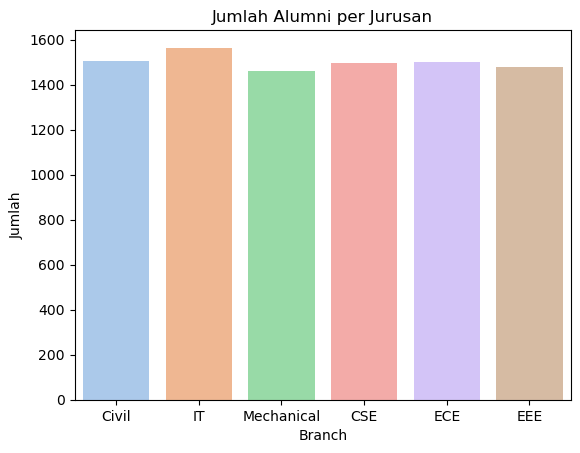

In [133]:
# Menampilkan jumlah alumni per jurusan
sns.countplot(x='branch', data=df, hue='branch', palette='pastel')
plt.title('Jumlah Alumni per Jurusan')
plt.xlabel('Branch')
plt.ylabel('Jumlah')
plt.show()

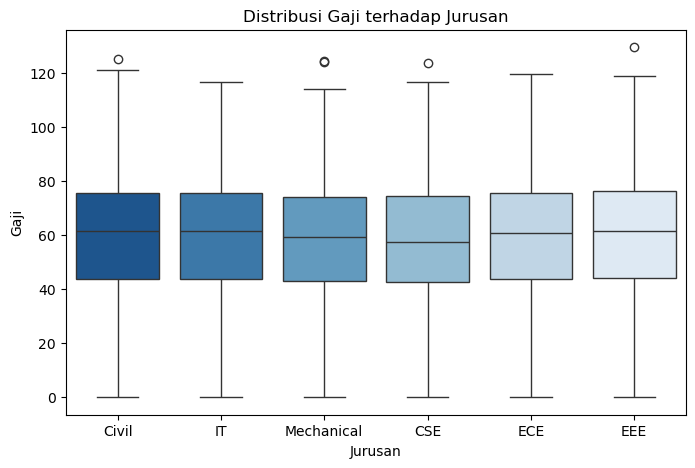

In [134]:
# Menampilkan box plot dari jurusan alumni dengan gaji yang di dapatkan
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='branch', y='salary_lpa', hue='branch',palette='Blues_r')
plt.title('Distribusi Gaji terhadap Jurusan')
plt.xlabel('Jurusan')
plt.ylabel('Gaji')
plt.show()

Berdasarkan hasil statistik deskriptif, rata-rata gaji antar jurusan cukup berdekatan dengan rata-rata diantara 54 hingga 57. Meskipun demikian, terdapat beberapa jurusan seperti Mechanical dan CSE yang memiliki nilai rata-rata gaji di bawah rata-rata gaji keseluruhan, yang mengindikasi adanya perbedaan gaji berdasarkan jurusan.


Pada boxplot yang disediakan, semua jurusan memiliki alumni yang tidak memiliki gaji karena belum mendapatkan pekerjaan. Tidak hanya itu, terdapat beberapa alumni di beberapa jurusan yang memiliki gaji di atas batas atas gaji per jurusan tersebut yang melebihi 120 LPA (Lakh Per Annum).

### Statistika Inferensial (Asumsi Hipotesis 1)

Hipotesa:\
H0: Tidak terdapat perbedaan rata-rata gaji yang signifikan antar jurusan\
H1: Terdapat setidaknya satu perbedaan rata-rata gaji yang signifikan antar jurusan

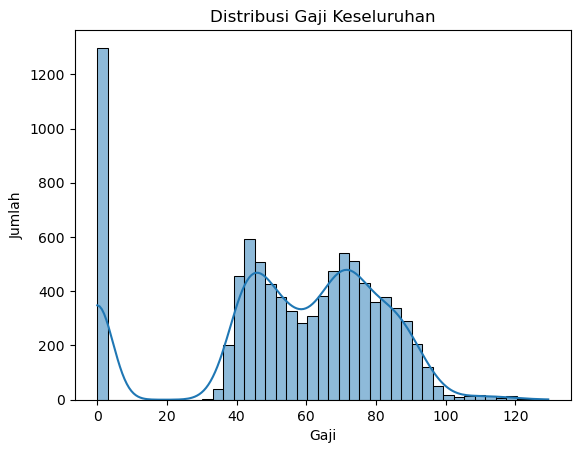

In [135]:
# Cek normalitas data secara visual menggunakan histogram dan buat garis kontinu sesuai dengan data histogram
sns.histplot(df['salary_lpa'], kde=True)
plt.title(f"Distribusi Gaji Keseluruhan")
plt.xlabel("Gaji")
plt.ylabel("Jumlah")
plt.show()


Grafik distribusi gaji di atas secara visual terlihat tidak normal, karena terdapat beberapa lonjakan gunung, terutama banyaknya alumni yang belum memiliki gaji.

In [136]:
# Cek skew setelah melakukan visualisasi dan komparasi hasil jawaban apakah sama atau tidak
p_skew = stats.skew(df['salary_lpa'])

# Tentukan distribusi data normal atau tidak
if -0.5 < p_skew < 0.5:
    print(f'Distribusi data normal dengan p-value {p_skew}')
else:
    print(f'Distribusi data tidak normal dengan p-value {p_skew}')

Distribusi data tidak normal dengan p-value -0.7535828259177383


Setelah diketahui bahwa data yang diolah tidak normal, gunakan fungsi korelasi kendall dan fungsi hipotesa Kruskal Wallis.


Tes korelasi Kendall Tau digunakan untuk mengetahui korelasi antara dua variabel non-parametrik.\
Tes hipotesa Kruskal Wallis digunakan untuk mengetahui signifikansi antara beberapa kelompok yang terasumsi distribusi data tidak normal.


Kedua tes ini dilakukan untuk mengetahui menjawab hipotesa yang sudah dikemukakan.

In [137]:
# Cek korelasi menggunakan fungsi kendall tau
tau, p_value = stats.kendalltau(df['branch'], df['salary_lpa'])
print(f'koefisien: {tau}')
if p_value < 0.05:
    print(f'Hasil ini bukan kebetulan dengan p-value {p_value}')
else:
    print(f'Hasil ini merupakan kebetulan dengan p-value {p_value}')

koefisien: 0.0018934145194073704
Hasil ini merupakan kebetulan dengan p-value 0.804782976119389


Sesuai dengan hasil perhitungan di atas, dapat dilihat bahwa angka koefisien menandakan tidak ada korelasi antara jurusan dengan tinggi gaji yang didapatkan walaupun memiliki p-value sebesar 0.8. Hasil tersebut bisa terjadi karena kebetulan dan tidak cukup sebagai bukti korelasi.

In [138]:
branch_group = [df[df['branch']== b]['salary_lpa'] for b in df['branch'].unique()]

statistik, p_kruskal = stats.kruskal(*branch_group)
print(f'Koefisien kruskal = {statistik} ')
print(f'P-value kruskal = {p_kruskal}')
print('')
if p_kruskal > 0.05:
    print("Hasil p-value dari tes kruskal wallis gagal menolak H0")
else:
    print("Hasil p-value dari tes kruskal wallis menolak H0")

Koefisien kruskal = 9.999706953477869 
P-value kruskal = 0.0752435499152455

Hasil p-value dari tes kruskal wallis gagal menolak H0


Hasil tes hipotesa menggunakan metode Kruskal Wallis menunjukkan bahwa p-value memiliki nilai 0.075 (lebih besar dari 0.05), sehingga gagal menolak hipotesis H0. Hal ini mengindikasi bahwa tidak terdapat perbedaan yang signifikan secara statistik pada gaji alumni dengan jurusan. Namun, karena adanya signifikansi, terdapat indikasi adanya perbedaan yang lemah, meskipun tidak cukup kuat untuk dinyatakan signifikan.

#### Histogram per branch

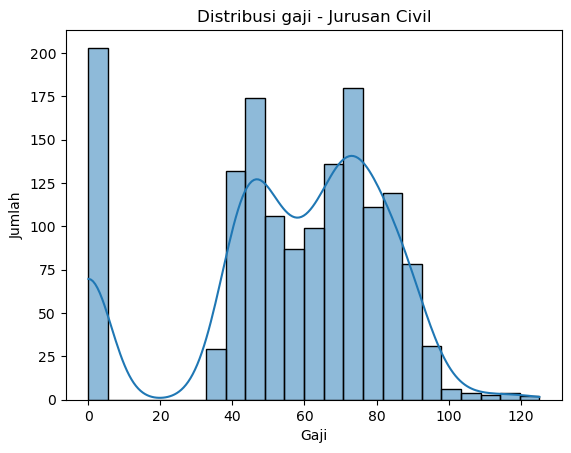

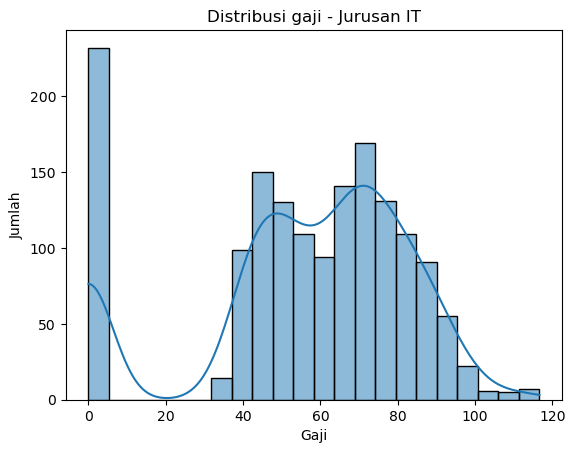

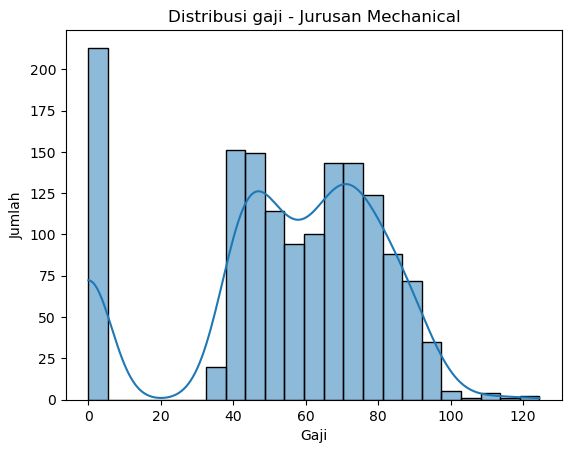

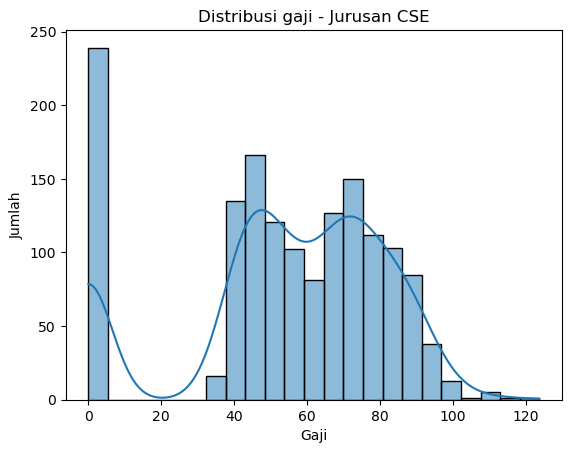

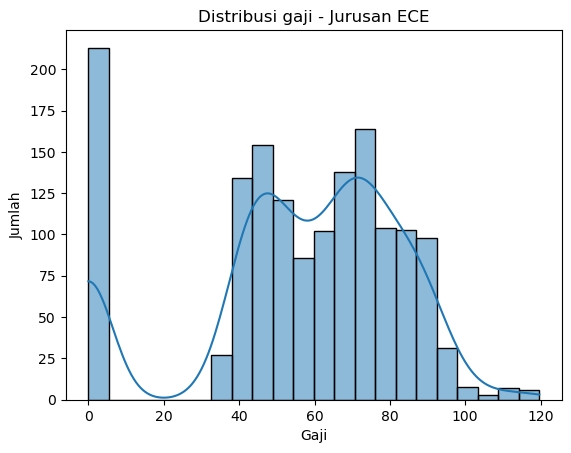

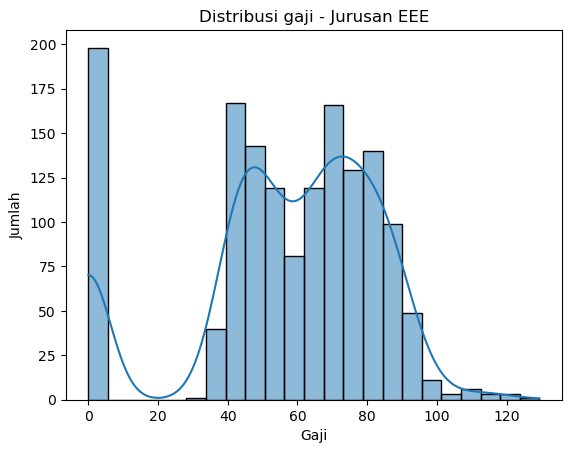

In [139]:

for b in df['branch'].unique():
    sns.histplot(df[df['branch'] == b]['salary_lpa'], kde=True)
    plt.title(f"Distribusi gaji - Jurusan {b}")
    plt.xlabel("Gaji")
    plt.ylabel("Jumlah")
    plt.show()


In [140]:
skew_branch = (
    df
    .groupby('branch')['salary_lpa']
    .apply(pd.Series.skew)
)

skew_branch


branch
CSE          -0.703474
Civil        -0.773814
ECE          -0.738800
EEE          -0.778066
IT           -0.779430
Mechanical   -0.754320
Name: salary_lpa, dtype: float64

### Statistika Deskriptif (Asumsi Hipotesis 2)

In [141]:
# Mencari rata-rata, median, dan standar deviasi dari CGPA
print('')
print(f'Mean CGPA: {df['cgpa'].mean()}')
print(f'Median CGPA: {df['cgpa'].median()}')
print(f'Standar Deviasi CGPA: {df['cgpa'].std()}')
print(f'Modus CGPA: {df['cgpa'].mode()[0]}')
print(f'Minimum CGPA: {df['cgpa'].min()}')
print(f'Maximum CGPA: {df['cgpa'].max()}')
print(f'Q1 CGPA: {df['cgpa'].quantile(0.25)}')
print(f'Q3 CGPA: {df['cgpa'].quantile(0.75)}')
print(f'IQR CGPA: {df['cgpa'].quantile(0.75) - df['cgpa'].quantile(0.25)}')        


Mean CGPA: 7.5072133333333335
Median CGPA: 7.5
Standar Deviasi CGPA: 1.4464955144406888
Modus CGPA: 8.69
Minimum CGPA: 5.0
Maximum CGPA: 10.0
Q1 CGPA: 6.2575
Q3 CGPA: 8.75
IQR CGPA: 2.4924999999999997


Rata-rata CGPA dari seluruh alumni adalah 7.5\
Median CGPA adalah 7.5\
Maksimum CPGA adalah 10 (perfect score)\
Minimum CGPA adalah 5\

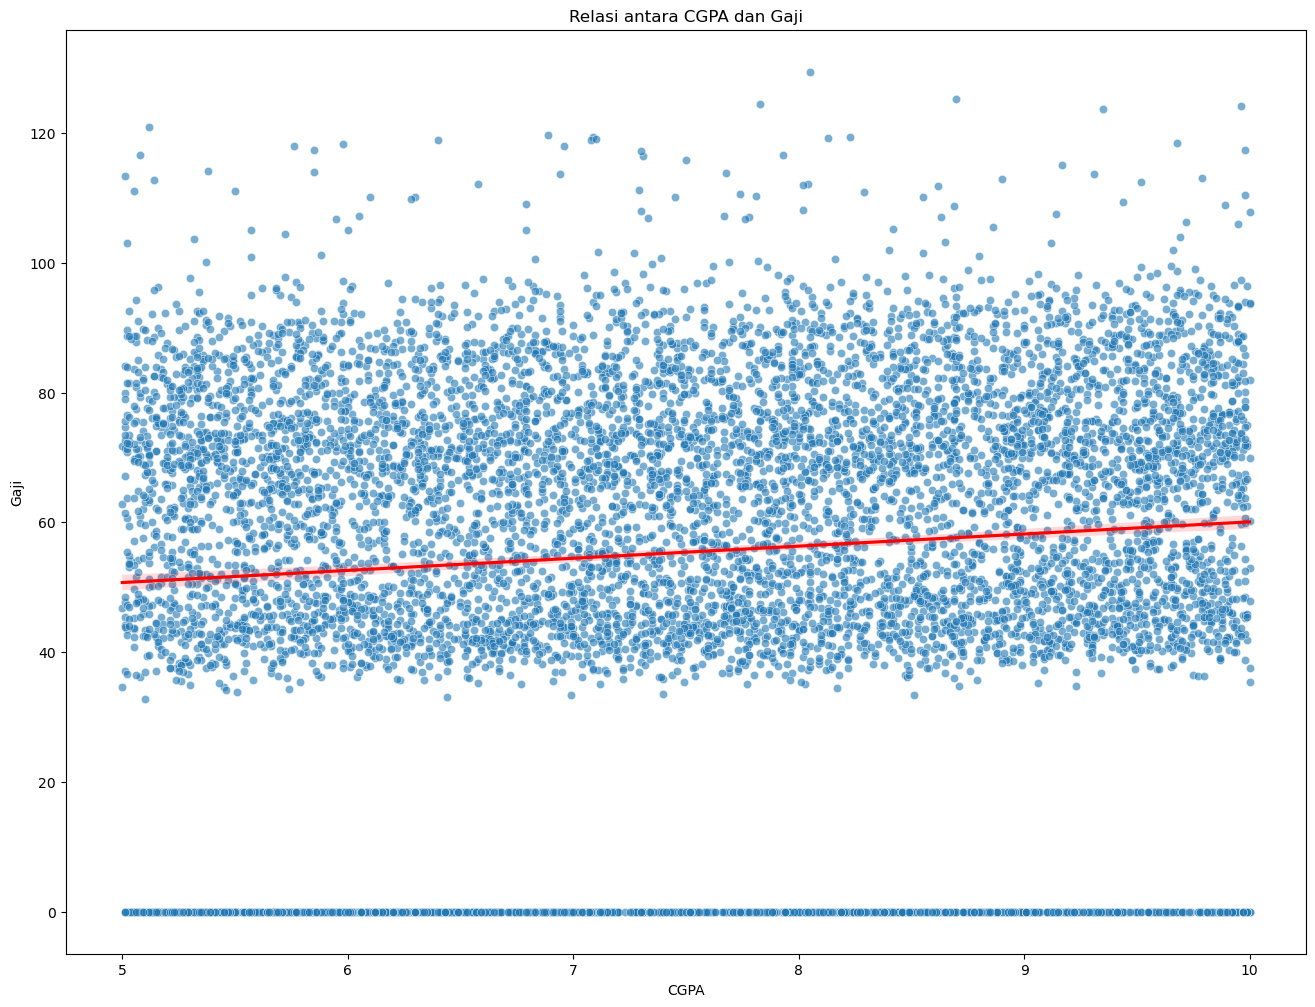

In [142]:
# Visualisasi perbandingan antara CGPA dengan Gaji
plt.figure(figsize=(16,12))
sns.scatterplot(x='cgpa', y='salary_lpa', data=df, alpha=0.6)

sns.regplot(
    x='cgpa',
    y='salary_lpa',
    data=df,
    scatter=False,
    color='red'
)

plt.title("Relasi antara CGPA dan Gaji")
plt.xlabel("CGPA")
plt.ylabel("Gaji")
plt.show()

Visualisasi di atas menggambarkan bahwa terdapat kenaikan pada kurva regresi berwarna merah. Jika dilihat dari kurva tersebut, semakin besar nilai yang diperoleh, semakin besar juga gaji yang dimiliki.

### Statistika Inferensial (Hipotesa 2)

Hipotesa:\
H0: Tidak terdapat hubungan yang signifikan antara CGPA dan Gaji\
H1: Terdapat setidaknya satu hubungan yang signifikan antara CGPA dan Gaji

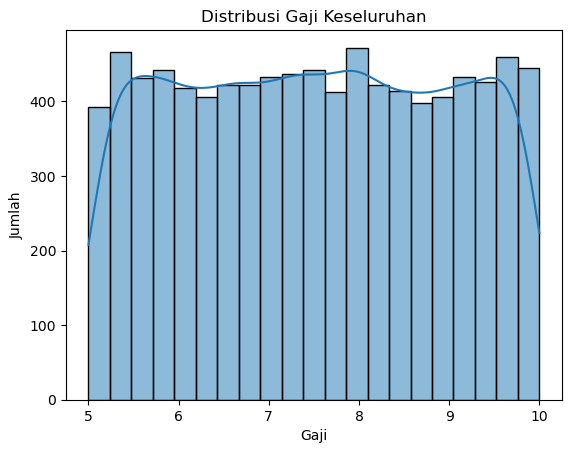

In [143]:
# Cek normalitas data dari kolom CGPA
sns.histplot(df['cgpa'], kde=True)
plt.title(f"Distribusi Gaji Keseluruhan")
plt.xlabel("Gaji")
plt.ylabel("Jumlah")
plt.show()

Secara visual data terlihat tidak normal dengan beberapa bukit dan lembah yang ada. Maka dari itu, lakukan triple check untuk menentukan normalitas data.

In [144]:
# Cek menggunakan metode skew()
p_skew = stats.skew(df['cgpa'])


print('Skew Method')
if -0.5 < p_skew < 0.5:
    print(f'Distribusi data normal dengan p-value {p_skew}')
else:
    print(f'Distribusi data tidak normal dengan p-value {p_skew}')

Skew Method
Distribusi data normal dengan p-value 0.0035028755748257845


In [145]:
# Cek menggunakan metode Shapiro-Wilk
stat, p_value = stats.shapiro(df['cgpa'])
print(f"Shapiro-Wilk p-value: {p_value}")

if p_value > 0.05:
    print("Data normal")
else:
    print("Data tidak normal")

Shapiro-Wilk p-value: 2.547104176237232e-46
Data tidak normal


c:\Users\bobe\anaconda3\envs\bootcamp\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9000.
  res = hypotest_fun_out(*samples, **kwds)


Hasil perhitungan metode skew menentukan bahwa grafik masih dalam distribusi normal. Namun, bentuk visual menentukan bahwa data tidak terdistribusi secara normal, sehingga harus dilakukan pengecekan ulang menggunakan metode lain, yaitu Shapiro-Wilk method. Hasil yang didapatkan adalah tidak normal sehingga distribusi merupakan non-parametrik.

Maka dari itu, dapat digunakan korelasi kendall tau untuk korelasi antara CGPA dengan Gaji.

In [148]:
# Cek korelasi menggunakan metode Kendall Tau
tau, p_value = stats.kendalltau(df['cgpa'], df['salary_lpa'])
print('Korelasi Tau')
print(f'Koefisien Tau: {tau}')
if p_value < 0.05:
    print(f'Hasil ini bukan kebetulan dengan p-value {p_value}')
else:
    print(f'Hasil ini merupakan kebetulan dengan p-value {p_value}')

Korelasi Tau
Koefisien Tau: 0.05753559401363165
Hasil ini bukan kebetulan dengan p-value 5.322937490568911e-16


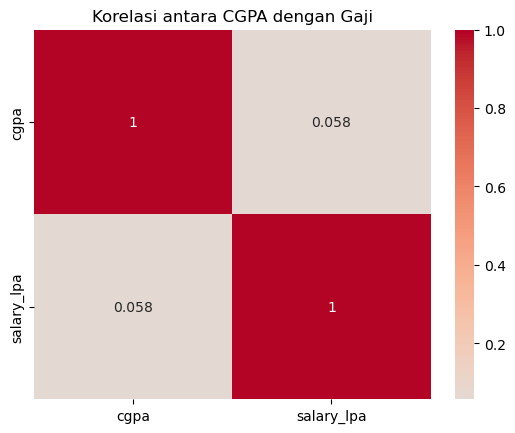

In [147]:
# Visualisasi hasil korelasi Kendall Tau menggunakan heatmap
kendall_corr = df[['cgpa', 'salary_lpa']].corr(method='kendall')

sns.heatmap(kendall_corr,annot=True,cmap='coolwarm',center=0)
plt.title("Korelasi antara CGPA dengan Gaji")
plt.show()


Hasil uji Kendall Tau menunjukkan bahwa adanya korelasi positif antara CGPA dengan Gaji (p-value < 0.05). Namun, nilai koefisien sangat kecil (Tau = 0.0575) yang mengindikasi bahwa ada hubungan tetapi lemah.

### Kesimpulan

Hipotesis 1: Apakah jurusan mempengaruhi gaji?


Jawaban: Tidak secara signifikan

Berdasarkan dua pengujian statistik:
- Kendall Tau menunjukkan koefisien korelasi yang sangat kecil antara jurusan dengan gaji (p-value sebesar 0.8). Artinya hubungan tersebut kemungkinan terjadi secara kebetulan.
- Kruskal-Wallis menginformasikan p-value sebesar 0.076 (alpha > 0.05), sehingga gagal menolak H0. Artinya tidak ada perbedaan rata-rata gaji yang signifikan secara statistik antar jurusan.


Meskipun secara deskriptif terlihat bahwa ada perbedaan seperti Mechanical dan CSE di bawah rata-rata keseluruhan, perbedaan ini tidak cukup kuat untuk dinyatakan bermakna secara statistik.

Hipotesis 2: Apakah CGPA berhubungan dengan gaji?


Jawaban: Ada hubungan, tapi sangat lemah

- Kendall Tau menunjukkan korelasi CGPA dan Gaji membuahkan korelasi positif yang signifikan dengan p-value di bawah 0.05, artinya hubungan ini bukan kebetulan.
- Namun, nilai koefisien tau yang dihasilkan (tau = 0.0575) sangat kecil sehingga kekuatan hubungannya sangat lemah, meskipun semakin tinggai CGPA cenderung menghasilkan Gaji lebih tinggi.

Temuan di atas menujukkan bahwa jurusan maupun nilai akademik tidak cukup untuk memprediksi gaji lulusan. Terdapat faktor lain pada dataset ini, seperti pengalaman magang, *softskill*, keterampilan teknis, dan lain-lain, memungkinkan menjadi pengaruh lebih besar terhadap gaji alumni. Oleh karena itu, analisa perlu melihat aspek yang lebih luas untuk meningkatkan kualitas dan daya saing lulusan untuk akreditasi sesuai dengan tujuan yang diinginkan.